# 04 - Segmentation et mesures

## Objectif
Construire une segmentation plus utile pour les pièces de fonderie en séparant :

1. les défauts externes (bord / couronne extérieure)
2. les défauts internes locaux (points, petites taches, anomalies locales)

## Logique
On va :

- préparer l’image
- segmenter la pièce principale
- construire deux zones d’intérêt :
  - une ROI extérieure
  - une ROI intérieure
- détecter les anomalies locales dans chaque ROI
- extraire des mesures simples :
  - nombre de régions
  - aire totale
  - aire maximale
  - ratio de surface suspecte

## Idée importante
Une seule segmentation globale ne suffit pas, car le dataset contient plusieurs types de défauts.

In [44]:
# ==========================================
# 1. Imports
# ==========================================

import sys
from pathlib import Path
sys.path.append(str(Path("..").resolve()))

%load_ext autoreload
%autoreload 2

import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random

from src.preprocessing import preprocess_image
from src.filtering import apply_median_filter

%matplotlib inline
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["image.cmap"] = "gray"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [45]:
# ==========================================
# 2. Dataset et fonctions utilitaires
# ==========================================

DATASET_DIR = Path("../data/raw/casting_data")

train_ok_dir = DATASET_DIR / "train" / "ok_front"
train_def_dir = DATASET_DIR / "train" / "def_front"

def list_images(folder):
    extensions = ["*.jpg", "*.jpeg", "*.png", "*.bmp", "*.tif", "*.tiff"]
    files = []
    for ext in extensions:
        files.extend(folder.glob(ext))
    return sorted(files)

def load_grayscale_image(image_path):
    img = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Impossible de lire l'image : {image_path}")
    return img

train_ok_images = list_images(train_ok_dir)
train_def_images = list_images(train_def_dir)

print(f"Train OK       : {len(train_ok_images)}")
print(f"Train Defective: {len(train_def_images)}")

Train OK       : 2875
Train Defective: 3758


In [133]:
# ==========================================
# 3. Choisir deux images exemple
# ==========================================

ok_path = random.choice(train_ok_images)
def_path = random.choice(train_def_images)

ok_img = load_grayscale_image(ok_path)
def_img = load_grayscale_image(def_path)

print("Image OK choisie       :", ok_path.name)
print("Image Defective choisie:", def_path.name)

Image OK choisie       : cast_ok_0_551.jpeg
Image Defective choisie: cast_def_0_7212.jpeg


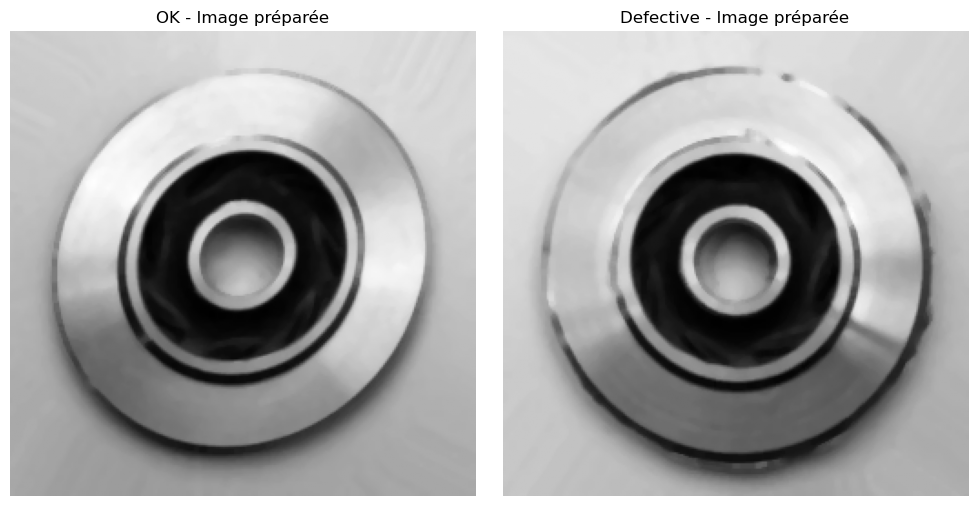

In [134]:
# ==========================================
# 4. Préparation des images
# ==========================================

def prepare_image(img, target_size=(256, 256)):
    img_pre = preprocess_image(img, target_size=target_size)
    img_filtered = apply_median_filter(img_pre, kernel_size=5)
    return img_filtered

ok_prepared = prepare_image(ok_img)
def_prepared = prepare_image(def_img)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(ok_prepared, cmap="gray")
axes[0].set_title("OK - Image préparée")
axes[0].axis("off")

axes[1].imshow(def_prepared, cmap="gray")
axes[1].set_title("Defective - Image préparée")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [135]:
# ==========================================
# 5. Nettoyage morphologique
# ==========================================

def morphological_cleaning(binary_img, kernel_size=3):
    kernel = np.ones((kernel_size, kernel_size), np.uint8)
    opened = cv2.morphologyEx(binary_img, cv2.MORPH_OPEN, kernel)
    cleaned = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel)
    return cleaned

In [136]:
# ==========================================
# 6. Segmentation de la pièce par cercle
# ==========================================

def detect_piece_circle(img_prepared, dp=1.2, min_dist=80, param1=100, param2=30,
                        min_radius=70, max_radius=120):
    """
    Détecte le cercle principal de la pièce avec HoughCircles.
    """
    blurred = cv2.GaussianBlur(img_prepared, (9, 9), 2)

    circles = cv2.HoughCircles(
        blurred,
        cv2.HOUGH_GRADIENT,
        dp=dp,
        minDist=min_dist,
        param1=param1,
        param2=param2,
        minRadius=min_radius,
        maxRadius=max_radius
    )

    if circles is None:
        return None

    circles = np.round(circles[0]).astype(int)

    H, W = img_prepared.shape
    img_cx, img_cy = W / 2, H / 2

    best_circle = None
    best_score = -1

    for x, y, r in circles:
        dist = np.sqrt((x - img_cx) ** 2 + (y - img_cy) ** 2)

        # privilégier cercle grand et proche du centre
        score = r - 0.5 * dist

        if score > best_score:
            best_score = score
            best_circle = (x, y, r)

    return best_circle


def segment_main_object_circle(img_prepared):
    """
    Segmente la pièce comme un disque principal.
    """
    circle = detect_piece_circle(img_prepared)

    if circle is None:
        # fallback simple si Hough échoue
        H, W = img_prepared.shape
        x, y = W // 2, H // 2
        r = int(0.34 * min(H, W))

        mask = np.zeros_like(img_prepared)
        cv2.circle(mask, (x, y), r, 255, thickness=-1)

        return {
            "mask": mask,
            "center": (x, y),
            "radius": r,
            "selected_mode": "FALLBACK_CIRCLE"
        }

    x, y, r = circle

    mask = np.zeros_like(img_prepared)
    cv2.circle(mask, (x, y), r, 255, thickness=-1)

    return {
        "mask": mask,
        "center": (x, y),
        "radius": r,
        "selected_mode": "HOUGH_CIRCLE"
    }

In [137]:
# ==========================================
# 7. Appliquer la segmentation de la pièce
# ==========================================

ok_main = segment_main_object_circle(ok_prepared)
def_main = segment_main_object_circle(def_prepared)

print("OK  -> mode choisi :", ok_main["selected_mode"], "| center :", ok_main["center"], "| radius :", ok_main["radius"])
print("DEF -> mode choisi :", def_main["selected_mode"], "| center :", def_main["center"], "| radius :", def_main["radius"])

print("Ratio blanc masque OK  :", np.mean(ok_main["mask"] == 255))
print("Ratio blanc masque DEF :", np.mean(def_main["mask"] == 255))

OK  -> mode choisi : HOUGH_CIRCLE | center : (np.int64(127), np.int64(133)) | radius : 101
DEF -> mode choisi : HOUGH_CIRCLE | center : (np.int64(130), np.int64(127)) | radius : 105
Ratio blanc masque OK  : 0.4885406494140625
Ratio blanc masque DEF : 0.5282745361328125


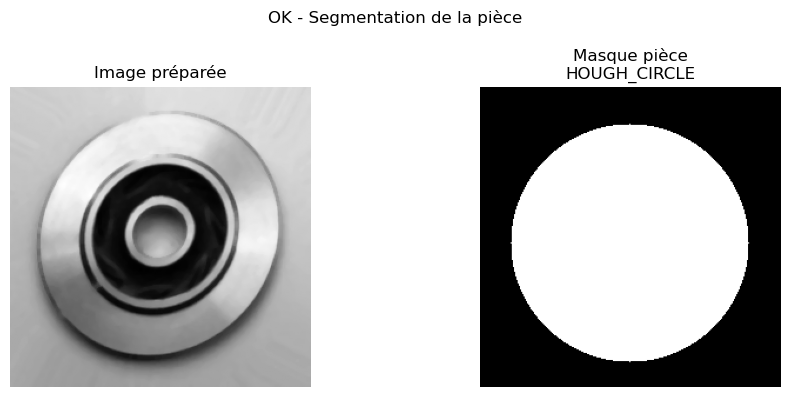

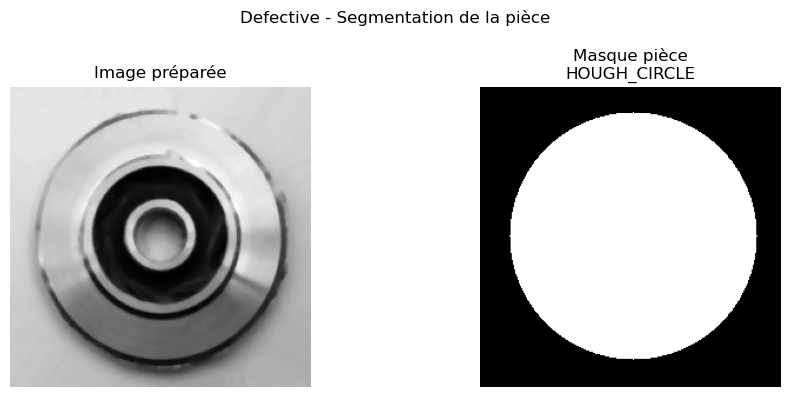

In [138]:
# ==========================================
# 8. Visualiser le masque pièce
# ==========================================

def show_circle_segmentation(prepared_img, result, title="Segmentation de la pièce"):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    axes[0].imshow(prepared_img, cmap="gray")
    axes[0].set_title("Image préparée")
    axes[0].axis("off")

    axes[1].imshow(result["mask"], cmap="gray")
    axes[1].set_title(f"Masque pièce\n{result['selected_mode']}")
    axes[1].axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

show_circle_segmentation(ok_prepared, ok_main, title="OK - Segmentation de la pièce")
show_circle_segmentation(def_prepared, def_main, title="Defective - Segmentation de la pièce")

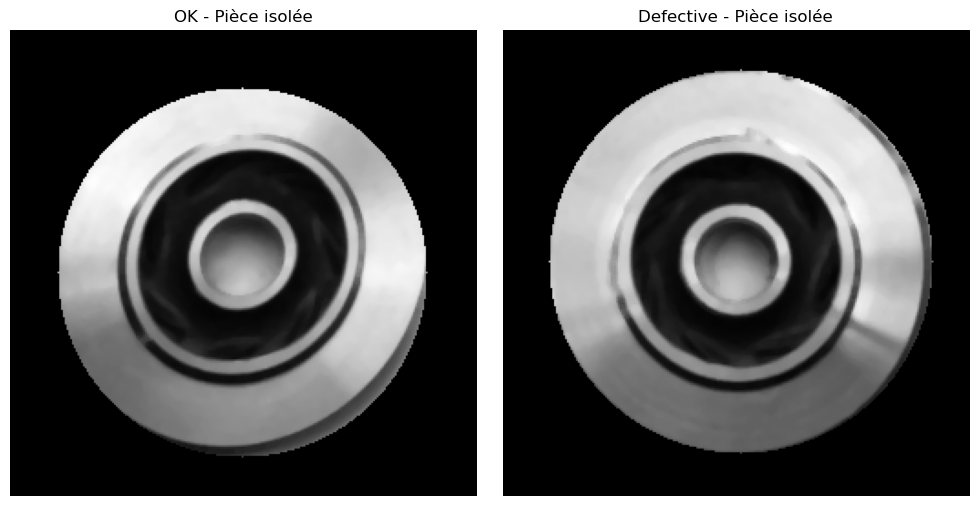

In [139]:
# ==========================================
# 9. Isoler la pièce
# ==========================================

def apply_mask(gray_img, mask):
    return cv2.bitwise_and(gray_img, gray_img, mask=mask)

ok_piece_only = apply_mask(ok_prepared, ok_main["mask"])
def_piece_only = apply_mask(def_prepared, def_main["mask"])

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(ok_piece_only, cmap="gray")
axes[0].set_title("OK - Pièce isolée")
axes[0].axis("off")

axes[1].imshow(def_piece_only, cmap="gray")
axes[1].set_title("Defective - Pièce isolée")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [140]:
# ==========================================
# 10. Centre et rayon de la pièce
# ==========================================

ok_center, ok_radius = ok_main["center"], ok_main["radius"]
def_center, def_radius = def_main["center"], def_main["radius"]

print("OK  -> center:", ok_center, "| radius:", ok_radius)
print("DEF -> center:", def_center, "| radius:", def_radius)

OK  -> center: (np.int64(127), np.int64(133)) | radius: 101
DEF -> center: (np.int64(130), np.int64(127)) | radius: 105


In [141]:
# ==========================================
# 11. ROI extérieure et ROI intérieure
# ==========================================

def create_annulus_mask(image_shape, center, r_inner, r_outer):
    mask = np.zeros(image_shape, dtype=np.uint8)
    cv2.circle(mask, center, int(r_outer), 255, thickness=-1)
    cv2.circle(mask, center, int(r_inner), 0, thickness=-1)
    return mask

# ROI extérieure : fine couronne proche du bord externe
ok_roi_outer = create_annulus_mask(
    ok_prepared.shape,
    ok_center,
    r_inner=0.90 * ok_radius,
    r_outer=0.995 * ok_radius
)

def_roi_outer = create_annulus_mask(
    def_prepared.shape,
    def_center,
    r_inner=0.90 * def_radius,
    r_outer=0.995 * def_radius
)

# ROI intérieure : zone interne utile, sans centre
ok_roi_inner = create_annulus_mask(
    ok_prepared.shape,
    ok_center,
    r_inner=0.48 * ok_radius,
    r_outer=0.70 * ok_radius
)

def_roi_inner = create_annulus_mask(
    def_prepared.shape,
    def_center,
    r_inner=0.48 * def_radius,
    r_outer=0.70 * def_radius
)

# limiter les ROI à la pièce
ok_roi_outer = cv2.bitwise_and(ok_roi_outer, ok_main["mask"])
def_roi_outer = cv2.bitwise_and(def_roi_outer, def_main["mask"])

ok_roi_inner = cv2.bitwise_and(ok_roi_inner, ok_main["mask"])
def_roi_inner = cv2.bitwise_and(def_roi_inner, def_main["mask"])

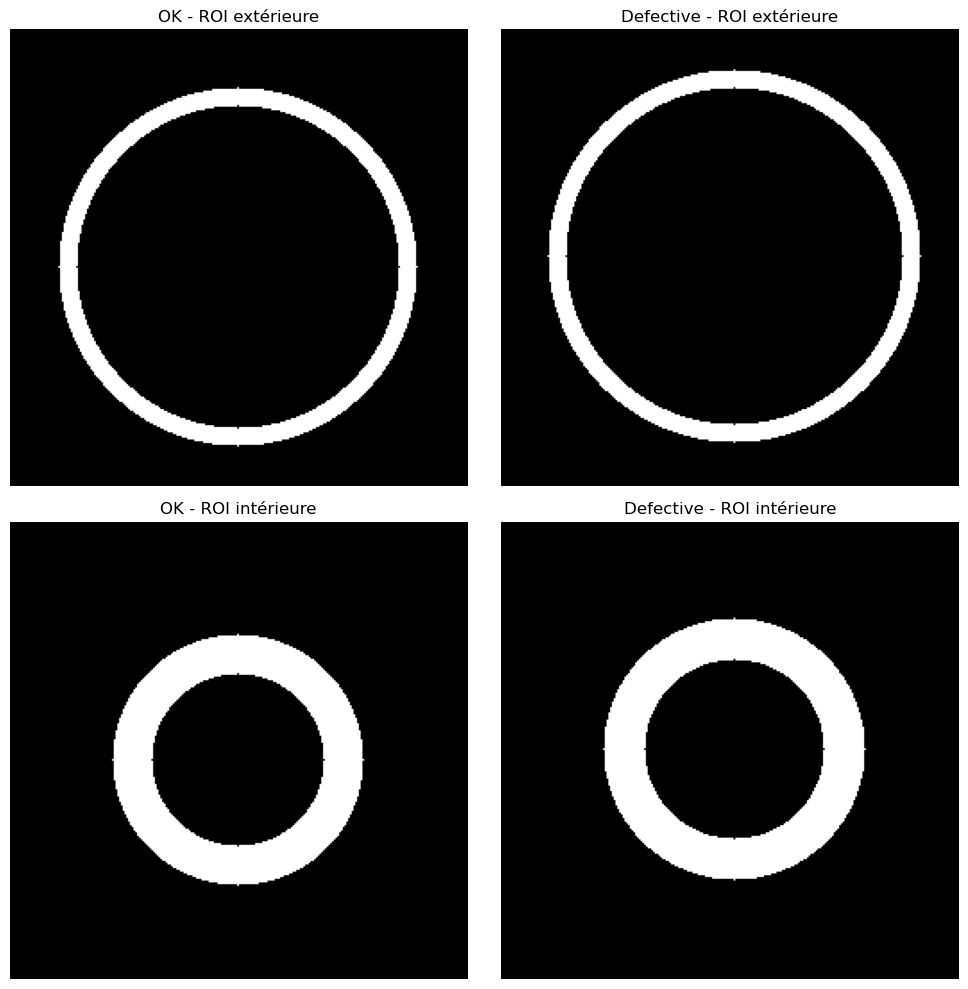

In [142]:
# ==========================================
# 12. Afficher les ROI
# ==========================================

fig, axes = plt.subplots(2, 2, figsize=(10, 10))

axes[0, 0].imshow(ok_roi_outer, cmap="gray")
axes[0, 0].set_title("OK - ROI extérieure")
axes[0, 0].axis("off")

axes[0, 1].imshow(def_roi_outer, cmap="gray")
axes[0, 1].set_title("Defective - ROI extérieure")
axes[0, 1].axis("off")

axes[1, 0].imshow(ok_roi_inner, cmap="gray")
axes[1, 0].set_title("OK - ROI intérieure")
axes[1, 0].axis("off")

axes[1, 1].imshow(def_roi_inner, cmap="gray")
axes[1, 1].set_title("Defective - ROI intérieure")
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()

In [143]:
# ==========================================
# 13. Fonctions contours
# ==========================================

def detect_contours(binary_img, retrieval_mode=cv2.RETR_EXTERNAL, approx_method=cv2.CHAIN_APPROX_SIMPLE):
    contours, hierarchy = cv2.findContours(binary_img.copy(), retrieval_mode, approx_method)
    return contours, hierarchy

def filter_contours_by_area(contours, min_area=20):
    return [cnt for cnt in contours if cv2.contourArea(cnt) >= min_area]

In [144]:
# ==========================================
# 14. Détection des anomalies dans une ROI
# ==========================================

def segment_anomalies_in_roi(
    piece_img,
    roi_mask,
    blur_size=31,
    min_area=20,
    max_area_ratio=0.08,
    sigma_factor=2.0,
    percentile=95,
    max_bbox_ratio=0.35
):
    """
    Détecte des anomalies locales dans une ROI donnée.
    Version corrigée :
    - résidu local
    - seuil modéré
    - connected components
    - filtrage par aire et taille de boîte
    """

    background = cv2.GaussianBlur(piece_img, (blur_size, blur_size), 0)

    # résidu local
    residual = cv2.absdiff(piece_img, background)

    # limiter à la ROI
    residual_roi = cv2.bitwise_and(residual, residual, mask=roi_mask)

    roi_values = residual_roi[roi_mask > 0]

    if roi_values.size == 0:
        return {
            "background": background,
            "residual": residual,
            "binary": np.zeros_like(residual_roi),
            "cleaned": np.zeros_like(residual_roi),
            "filtered_contours": [],
            "suspicious_mask": np.zeros_like(residual_roi),
            "threshold_value": 0
        }

    # seuil moins strict
    thr_mean_std = float(roi_values.mean() + sigma_factor * roi_values.std())
    thr_percentile = float(np.percentile(roi_values, percentile))
    threshold_value = max(8.0, min(thr_mean_std, thr_percentile))

    binary = np.zeros_like(residual_roi)
    binary[residual_roi >= threshold_value] = 255

    binary = cv2.bitwise_and(binary, binary, mask=roi_mask)

    cleaned = morphological_cleaning(binary, kernel_size=3)

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(cleaned, connectivity=8)

    H, W = cleaned.shape
    roi_area = np.sum(roi_mask == 255)
    max_area_allowed = max_area_ratio * roi_area

    suspicious_mask = np.zeros_like(cleaned)

    for label in range(1, num_labels):
        x = stats[label, cv2.CC_STAT_LEFT]
        y = stats[label, cv2.CC_STAT_TOP]
        w = stats[label, cv2.CC_STAT_WIDTH]
        h = stats[label, cv2.CC_STAT_HEIGHT]
        area = stats[label, cv2.CC_STAT_AREA]

        if area < min_area:
            continue
        if area > max_area_allowed:
            continue
        if w > max_bbox_ratio * W:
            continue
        if h > max_bbox_ratio * H:
            continue

        suspicious_mask[labels == label] = 255

    contours, _ = detect_contours(suspicious_mask)
    filtered_contours = filter_contours_by_area(contours, min_area=min_area)

    return {
        "background": background,
        "residual": residual,
        "binary": binary,
        "cleaned": cleaned,
        "filtered_contours": filtered_contours,
        "suspicious_mask": suspicious_mask,
        "threshold_value": threshold_value
    }

In [154]:
# ==========================================
# 15. Analyse des défauts extérieurs par continuité d'arête
# ==========================================

def analyze_outer_edge_continuity(
    piece_img,
    roi_mask,
    center,
    blur_size=5,
    canny1=40,
    canny2=120,
    nbins=180,
    min_component_pixels=5
):
    """
    Analyse la continuité du bord extérieur.
    Idée :
    - détecter les arêtes dans la ROI extérieure
    - mesurer la couverture angulaire
    - mesurer le plus grand gap angulaire
    """
    blurred = cv2.GaussianBlur(piece_img, (blur_size, blur_size), 0)

    edges = cv2.Canny(blurred, canny1, canny2)
    edge_roi = cv2.bitwise_and(edges, edges, mask=roi_mask)

    # petit nettoyage/liaison des arêtes
    kernel = np.ones((3, 3), np.uint8)
    edge_roi = cv2.morphologyEx(edge_roi, cv2.MORPH_CLOSE, kernel)

    # connected components pour enlever les très petits artefacts
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(edge_roi, connectivity=8)

    filtered_edges = np.zeros_like(edge_roi)
    num_components = 0
    edge_pixels = 0

    for label in range(1, num_labels):
        area = stats[label, cv2.CC_STAT_AREA]
        if area >= min_component_pixels:
            filtered_edges[labels == label] = 255
            num_components += 1
            edge_pixels += int(area)

    ys, xs = np.where(filtered_edges > 0)

    occupied = np.zeros(nbins, dtype=bool)

    if len(xs) > 0:
        angles = np.arctan2(ys - center[1], xs - center[0])
        angles = (angles + 2 * np.pi) % (2 * np.pi)

        bins = (angles / (2 * np.pi) * nbins).astype(int)
        bins = np.clip(bins, 0, nbins - 1)

        occupied[np.unique(bins)] = True

    coverage_ratio = float(np.mean(occupied))

    # calcul du plus grand gap circulaire
    empty = ~occupied
    if np.all(empty):
        largest_gap_len = nbins
        largest_gap_start = 0
    else:
        doubled = np.concatenate([empty, empty])

        best_len = 0
        best_start = 0
        cur_len = 0
        cur_start = 0

        for i, val in enumerate(doubled):
            if val:
                if cur_len == 0:
                    cur_start = i
                cur_len += 1

                if cur_len > best_len and cur_start < nbins:
                    best_len = cur_len
                    best_start = cur_start
            else:
                cur_len = 0

        largest_gap_len = min(best_len, nbins)
        largest_gap_start = best_start % nbins

    largest_gap_ratio = float(largest_gap_len / nbins)

    # construire un masque visuel du plus grand gap angulaire
    gap_bins = np.zeros(nbins, dtype=bool)
    if largest_gap_len > 0:
        idx = (np.arange(largest_gap_len) + largest_gap_start) % nbins
        gap_bins[idx] = True

    gap_mask = np.zeros_like(roi_mask)
    roi_ys, roi_xs = np.where(roi_mask > 0)

    if len(roi_xs) > 0:
        roi_angles = np.arctan2(roi_ys - center[1], roi_xs - center[0])
        roi_angles = (roi_angles + 2 * np.pi) % (2 * np.pi)

        roi_bins = (roi_angles / (2 * np.pi) * nbins).astype(int)
        roi_bins = np.clip(roi_bins, 0, nbins - 1)

        gap_pixels = gap_bins[roi_bins]
        gap_mask[roi_ys[gap_pixels], roi_xs[gap_pixels]] = 255

    return {
        "edges": edges,
        "edge_roi": edge_roi,
        "filtered_edges": filtered_edges,
        "num_components": num_components,
        "edge_pixels": edge_pixels,
        "coverage_ratio": coverage_ratio,
        "largest_gap_ratio": largest_gap_ratio,
        "gap_mask": gap_mask
    }


# Application sur l'exemple courant
ok_outer = analyze_outer_edge_continuity(
    ok_piece_only,
    ok_roi_outer,
    center=ok_center,
    blur_size=5,
    canny1=40,
    canny2=120,
    nbins=180,
    min_component_pixels=5
)

def_outer = analyze_outer_edge_continuity(
    def_piece_only,
    def_roi_outer,
    center=def_center,
    blur_size=5,
    canny1=40,
    canny2=120,
    nbins=180,
    min_component_pixels=5
)

print("OK  - outer num_components :", ok_outer["num_components"])
print("DEF - outer num_components :", def_outer["num_components"])
print("OK  - outer coverage_ratio :", round(ok_outer["coverage_ratio"], 4))
print("DEF - outer coverage_ratio :", round(def_outer["coverage_ratio"], 4))
print("OK  - outer largest_gap_ratio :", round(ok_outer["largest_gap_ratio"], 4))
print("DEF - outer largest_gap_ratio :", round(def_outer["largest_gap_ratio"], 4))

OK  - outer num_components : 1
DEF - outer num_components : 2
OK  - outer coverage_ratio : 0.3222
DEF - outer coverage_ratio : 0.3278
OK  - outer largest_gap_ratio : 0.6778
DEF - outer largest_gap_ratio : 0.6722


In [155]:
# ==========================================
# 16. Application sur la ROI intérieure
# ==========================================

ok_inner = segment_anomalies_in_roi(
    ok_piece_only,
    ok_roi_inner,
    blur_size=31,
    min_area=10,
    max_area_ratio=0.10,
    sigma_factor=2.0,
    percentile=95,
    max_bbox_ratio=0.35
)

def_inner = segment_anomalies_in_roi(
    def_piece_only,
    def_roi_inner,
    blur_size=31,
    min_area=10,
    max_area_ratio=0.10,
    sigma_factor=2.0,
    percentile=95,
    max_bbox_ratio=0.35
)

print("OK  - régions intérieures :", len(ok_inner["filtered_contours"]))
print("DEF - régions intérieures :", len(def_inner["filtered_contours"]))
print("Seuil inner OK  :", round(ok_inner["threshold_value"], 2))
print("Seuil inner DEF :", round(def_inner["threshold_value"], 2))

OK  - régions intérieures : 3
DEF - régions intérieures : 3
Seuil inner OK  : 73.0
Seuil inner DEF : 62.0


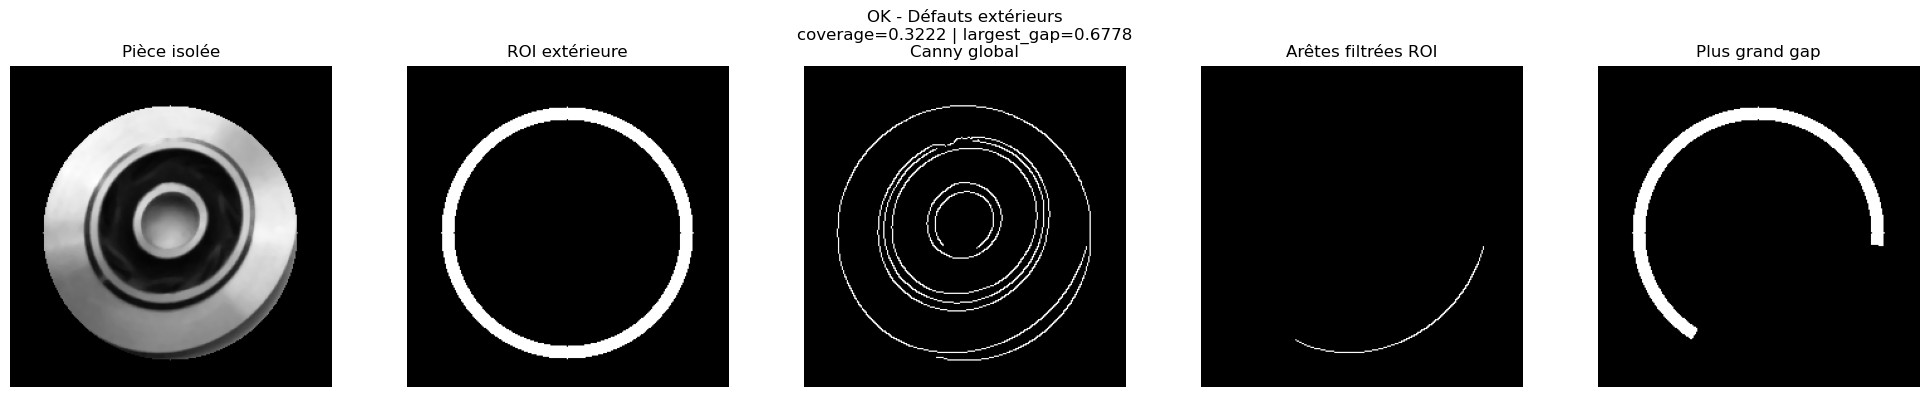

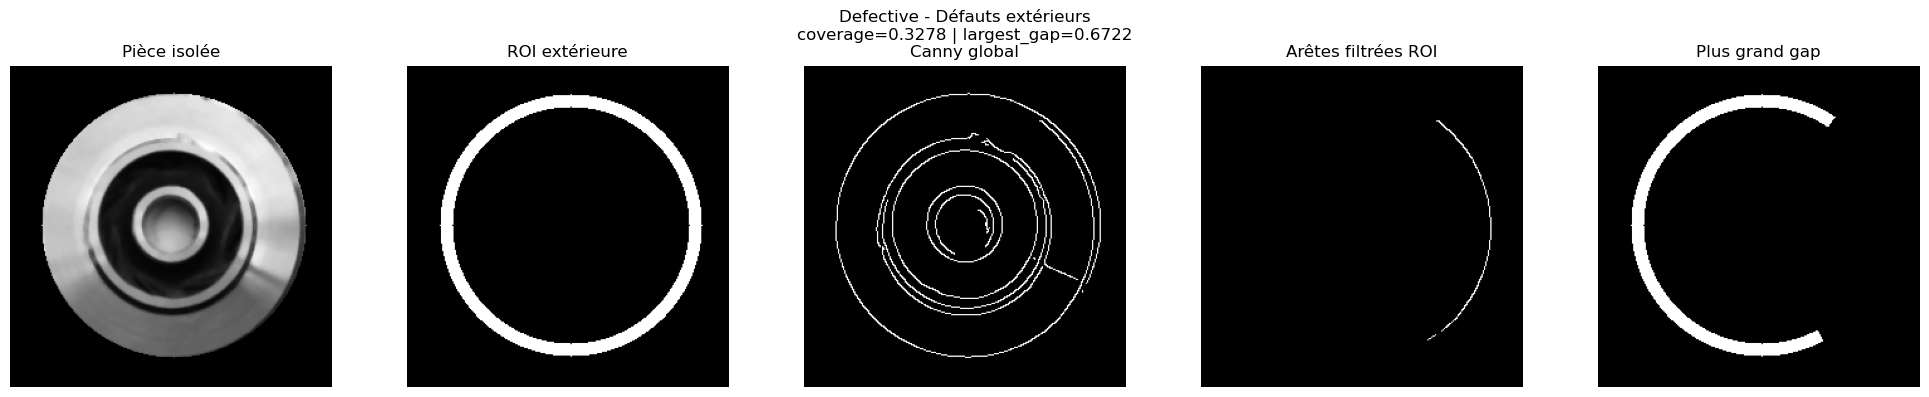

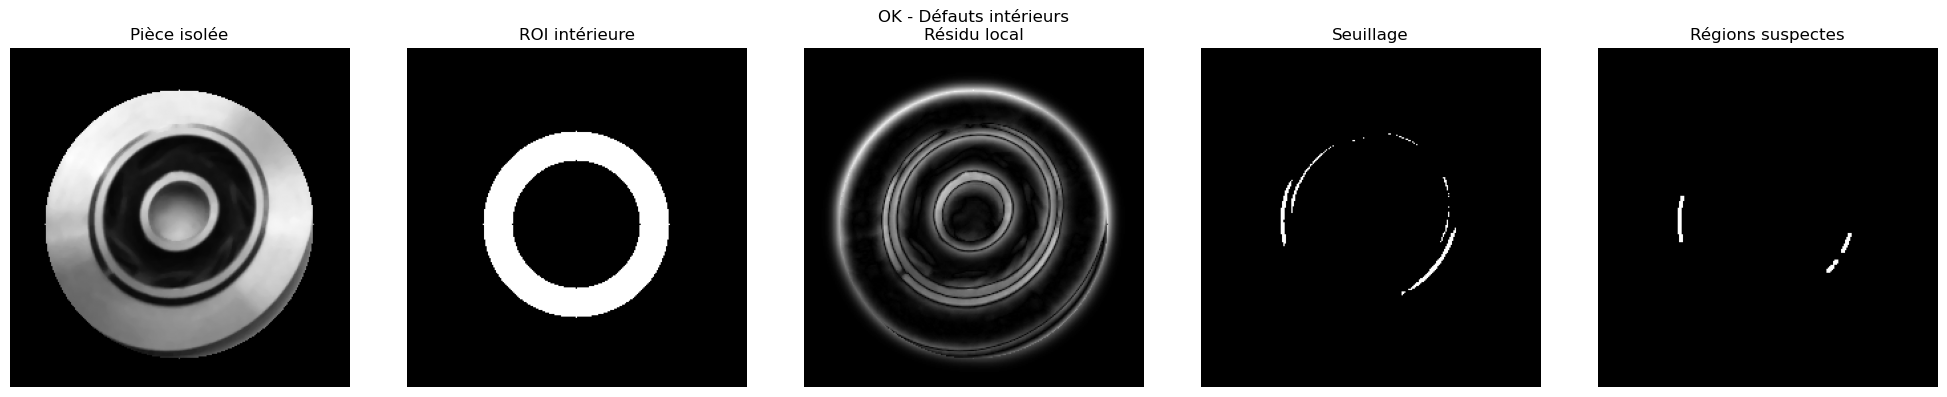

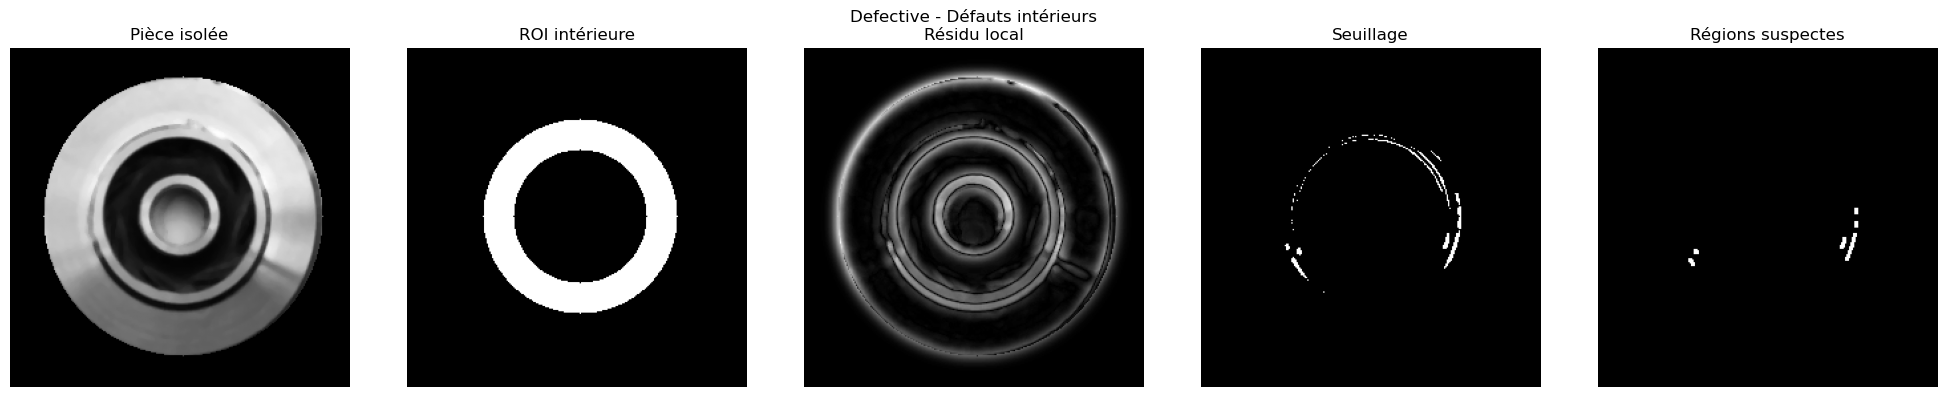

In [157]:
# ==========================================
# 17. Visualisation détaillée
# ==========================================

def show_outer_edge_analysis(piece_img, roi_mask, result, title="Analyse des défauts extérieurs"):
    fig, axes = plt.subplots(1, 5, figsize=(20, 4))

    axes[0].imshow(piece_img, cmap="gray")
    axes[0].set_title("Pièce isolée")
    axes[0].axis("off")

    axes[1].imshow(roi_mask, cmap="gray")
    axes[1].set_title("ROI extérieure")
    axes[1].axis("off")

    axes[2].imshow(result["edges"], cmap="gray")
    axes[2].set_title("Canny global")
    axes[2].axis("off")

    axes[3].imshow(result["filtered_edges"], cmap="gray")
    axes[3].set_title("Arêtes filtrées ROI")
    axes[3].axis("off")

    axes[4].imshow(result["gap_mask"], cmap="gray")
    axes[4].set_title("Plus grand gap")
    axes[4].axis("off")

    plt.suptitle(
        f"{title}\ncoverage={result['coverage_ratio']:.4f} | largest_gap={result['largest_gap_ratio']:.4f}"
    )
    plt.tight_layout()
    plt.show()


def show_inner_segmentation(piece_img, roi_mask, result, title="Défauts intérieurs"):
    fig, axes = plt.subplots(1, 5, figsize=(20, 4))

    axes[0].imshow(piece_img, cmap="gray")
    axes[0].set_title("Pièce isolée")
    axes[0].axis("off")

    axes[1].imshow(roi_mask, cmap="gray")
    axes[1].set_title("ROI intérieure")
    axes[1].axis("off")

    axes[2].imshow(result["residual"], cmap="gray")
    axes[2].set_title("Résidu local")
    axes[2].axis("off")

    axes[3].imshow(result["binary"], cmap="gray")
    axes[3].set_title("Seuillage")
    axes[3].axis("off")

    axes[4].imshow(result["suspicious_mask"], cmap="gray")
    axes[4].set_title("Régions suspectes")
    axes[4].axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


show_outer_edge_analysis(ok_piece_only, ok_roi_outer, ok_outer, title="OK - Défauts extérieurs")
show_outer_edge_analysis(def_piece_only, def_roi_outer, def_outer, title="Defective - Défauts extérieurs")

show_inner_segmentation(ok_piece_only, ok_roi_inner, ok_inner, title="OK - Défauts intérieurs")
show_inner_segmentation(def_piece_only, def_roi_inner, def_inner, title="Defective - Défauts intérieurs")

In [158]:
# ==========================================
# 18. Fonctions de mesures
# ==========================================

def summarize_contours(contours):
    if len(contours) == 0:
        return {
            "num_contours": 0,
            "total_area": 0.0,
            "max_area": 0.0,
            "mean_area": 0.0,
            "total_perimeter": 0.0
        }

    areas = [cv2.contourArea(c) for c in contours]
    perimeters = [cv2.arcLength(c, True) for c in contours]

    return {
        "num_contours": len(contours),
        "total_area": float(np.sum(areas)),
        "max_area": float(np.max(areas)),
        "mean_area": float(np.mean(areas)),
        "total_perimeter": float(np.sum(perimeters))
    }

def area_ratio(reference_mask, suspicious_mask):
    ref_area = np.sum(reference_mask == 255)
    suspicious_area = np.sum(suspicious_mask == 255)

    if ref_area == 0:
        return 0.0

    return suspicious_area / ref_area

In [159]:
# ==========================================
# 19. Résumé OK vs Defective
# ==========================================

ok_inner_summary = summarize_contours(ok_inner["filtered_contours"])
def_inner_summary = summarize_contours(def_inner["filtered_contours"])

ok_inner_ratio = area_ratio(ok_roi_inner, ok_inner["suspicious_mask"])
def_inner_ratio = area_ratio(def_roi_inner, def_inner["suspicious_mask"])

print("=== OK ===")
print("Outer :")
print(" - num_components   :", ok_outer["num_components"])
print(" - edge_pixels      :", ok_outer["edge_pixels"])
print(" - coverage_ratio   :", round(ok_outer["coverage_ratio"], 6))
print(" - largest_gap_ratio:", round(ok_outer["largest_gap_ratio"], 6))

print("Inner :")
print(" - num_contours     :", ok_inner_summary["num_contours"])
print(" - total_area       :", round(ok_inner_summary["total_area"], 2))
print(" - max_area         :", round(ok_inner_summary["max_area"], 2))
print(" - inner_area_ratio :", round(ok_inner_ratio, 6))

print("\n=== Defective ===")
print("Outer :")
print(" - num_components   :", def_outer["num_components"])
print(" - edge_pixels      :", def_outer["edge_pixels"])
print(" - coverage_ratio   :", round(def_outer["coverage_ratio"], 6))
print(" - largest_gap_ratio:", round(def_outer["largest_gap_ratio"], 6))

print("Inner :")
print(" - num_contours     :", def_inner_summary["num_contours"])
print(" - total_area       :", round(def_inner_summary["total_area"], 2))
print(" - max_area         :", round(def_inner_summary["max_area"], 2))
print(" - inner_area_ratio :", round(def_inner_ratio, 6))

=== OK ===
Outer :
 - num_components   : 1
 - edge_pixels      : 222
 - coverage_ratio   : 0.322222
 - largest_gap_ratio: 0.677778
Inner :
 - num_contours     : 3
 - total_area       : 125.0
 - max_area         : 68.0
 - inner_area_ratio : 0.023529

=== Defective ===
Outer :
 - num_components   : 2
 - edge_pixels      : 232
 - coverage_ratio   : 0.327778
 - largest_gap_ratio: 0.672222
Inner :
 - num_contours     : 3
 - total_area       : 74.0
 - max_area         : 42.0
 - inner_area_ratio : 0.018122


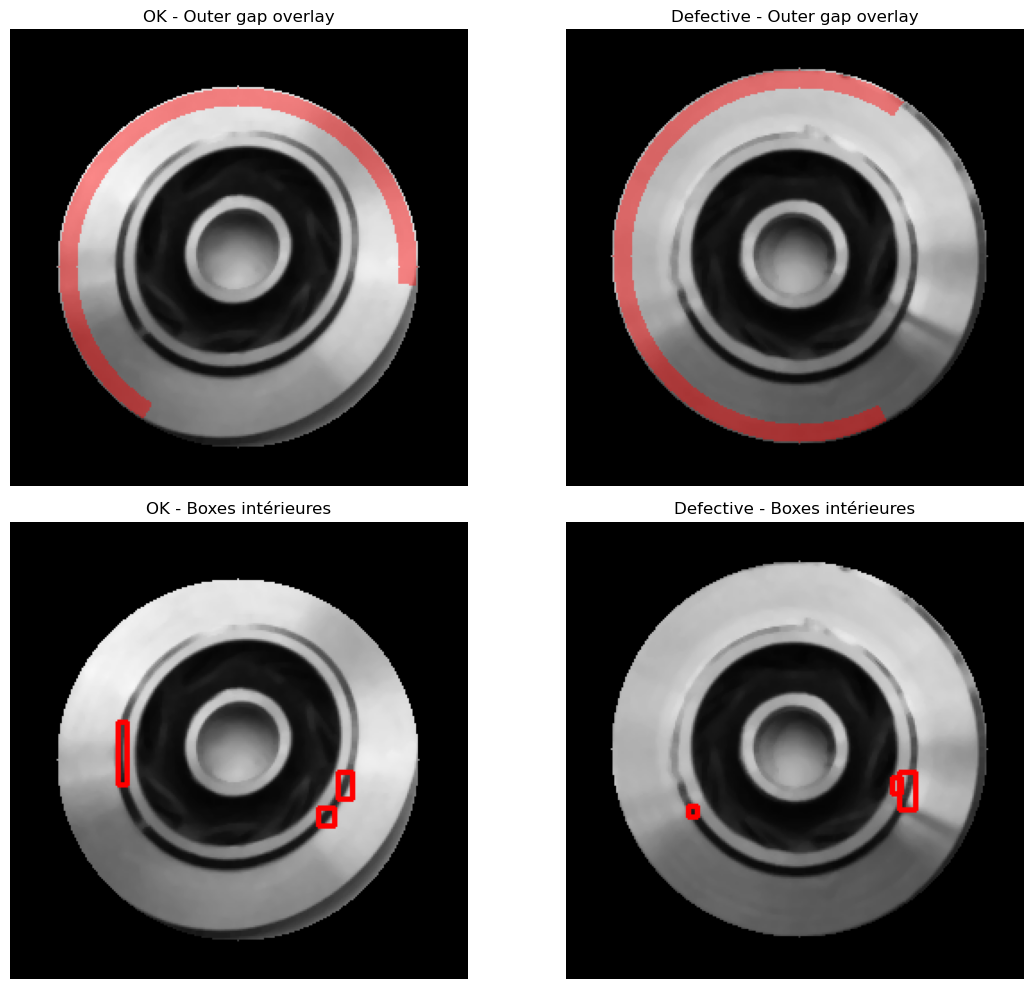

In [160]:
# ==========================================
# 20. Affichage final outer + inner
# ==========================================

def overlay_mask_on_gray(gray_img, mask, color=(255, 0, 0), alpha=0.5):
    rgb = cv2.cvtColor(gray_img, cv2.COLOR_GRAY2RGB)
    overlay = rgb.copy()
    overlay[mask > 0] = color
    blended = cv2.addWeighted(overlay, alpha, rgb, 1 - alpha, 0)
    return blended

def draw_bounding_boxes(gray_img, contours, thickness=2, min_area=10):
    img_rgb = cv2.cvtColor(gray_img, cv2.COLOR_GRAY2RGB)

    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < min_area:
            continue

        x, y, w, h = cv2.boundingRect(cnt)
        cv2.rectangle(img_rgb, (x, y), (x + w, y + h), (255, 0, 0), thickness)

    return img_rgb

ok_outer_overlay = overlay_mask_on_gray(ok_piece_only, ok_outer["gap_mask"], color=(255, 0, 0), alpha=0.45)
def_outer_overlay = overlay_mask_on_gray(def_piece_only, def_outer["gap_mask"], color=(255, 0, 0), alpha=0.45)

ok_inner_boxes = draw_bounding_boxes(ok_piece_only, ok_inner["filtered_contours"], min_area=10)
def_inner_boxes = draw_bounding_boxes(def_piece_only, def_inner["filtered_contours"], min_area=10)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].imshow(ok_outer_overlay)
axes[0, 0].set_title("OK - Outer gap overlay")
axes[0, 0].axis("off")

axes[0, 1].imshow(def_outer_overlay)
axes[0, 1].set_title("Defective - Outer gap overlay")
axes[0, 1].axis("off")

axes[1, 0].imshow(ok_inner_boxes)
axes[1, 0].set_title("OK - Boxes intérieures")
axes[1, 0].axis("off")

axes[1, 1].imshow(def_inner_boxes)
axes[1, 1].set_title("Defective - Boxes intérieures")
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()

In [163]:
# ==========================================
# 21. Extraire les features d'une image
# ==========================================

def extract_features_from_result(result):
    inner_summary = summarize_contours(result["inner"]["filtered_contours"])
    inner_ratio = area_ratio(result["roi_inner"], result["inner"]["suspicious_mask"])

    return {
        "outer_num_components": result["outer"]["num_components"],
        "outer_edge_pixels": result["outer"]["edge_pixels"],
        "outer_coverage_ratio": result["outer"]["coverage_ratio"],
        "outer_largest_gap_ratio": result["outer"]["largest_gap_ratio"],

        "inner_num_contours": inner_summary["num_contours"],
        "inner_total_area": inner_summary["total_area"],
        "inner_max_area": inner_summary["max_area"],
        "inner_mean_area": inner_summary["mean_area"],
        "inner_total_perimeter": inner_summary["total_perimeter"],
        "inner_area_ratio": inner_ratio,
    }

In [164]:
# ==========================================
# 22. Pipeline complet
# ==========================================

def full_segmentation_pipeline_v2(img):
    prepared = prepare_image(img)

    main_obj = segment_main_object_circle(prepared)
    piece_only = apply_mask(prepared, main_obj["mask"])

    if main_obj["center"] is None:
        return None

    center, radius = main_obj["center"], main_obj["radius"]

    roi_outer = create_annulus_mask(
        prepared.shape,
        center,
        r_inner=0.90 * radius,
        r_outer=0.995 * radius
    )

    roi_inner = create_annulus_mask(
        prepared.shape,
        center,
        r_inner=0.48 * radius,
        r_outer=0.70 * radius
    )

    roi_outer = cv2.bitwise_and(roi_outer, main_obj["mask"])
    roi_inner = cv2.bitwise_and(roi_inner, main_obj["mask"])

    outer = analyze_outer_edge_continuity(
        piece_only,
        roi_outer,
        center=center,
        blur_size=5,
        canny1=40,
        canny2=120,
        nbins=180,
        min_component_pixels=5
    )

    inner = segment_anomalies_in_roi(
        piece_only,
        roi_inner,
        blur_size=31,
        min_area=10,
        max_area_ratio=0.10,
        sigma_factor=2.0,
        percentile=95,
        max_bbox_ratio=0.35
    )

    return {
        "prepared": prepared,
        "main_obj": main_obj,
        "piece_only": piece_only,
        "roi_outer": roi_outer,
        "roi_inner": roi_inner,
        "outer": outer,
        "inner": inner
    }

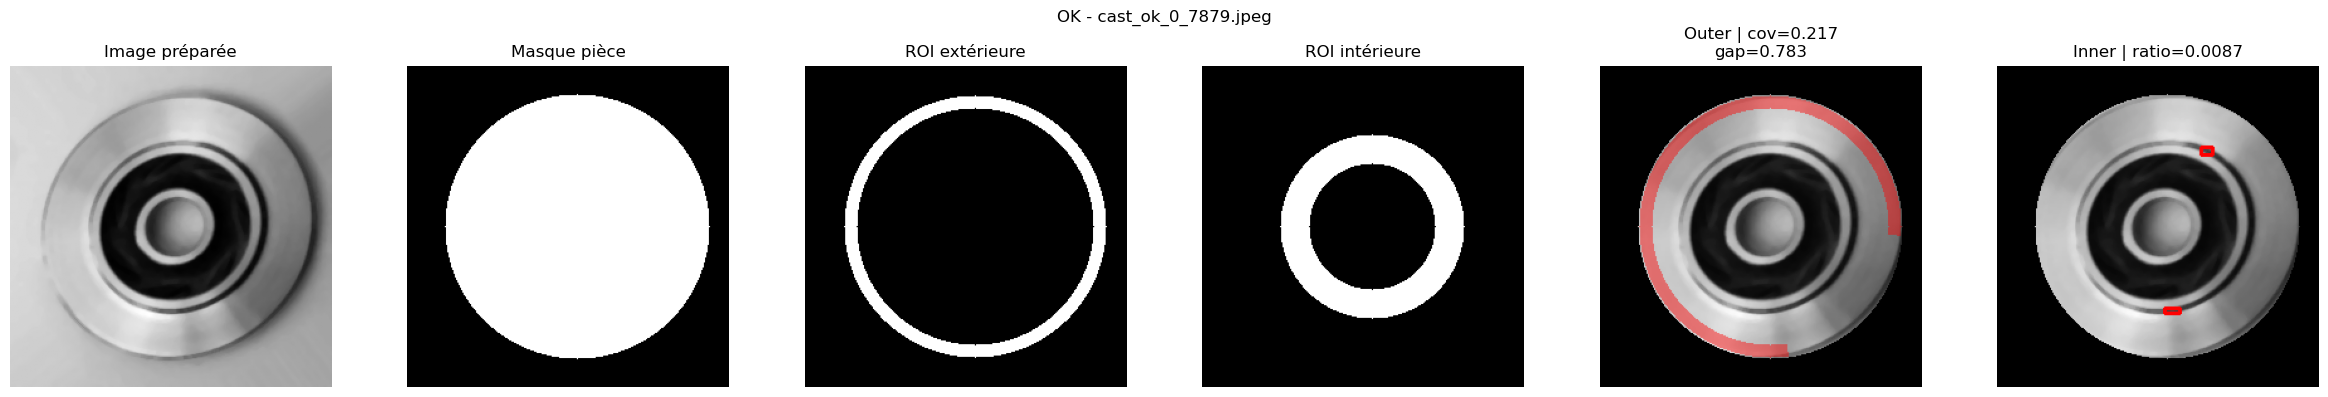

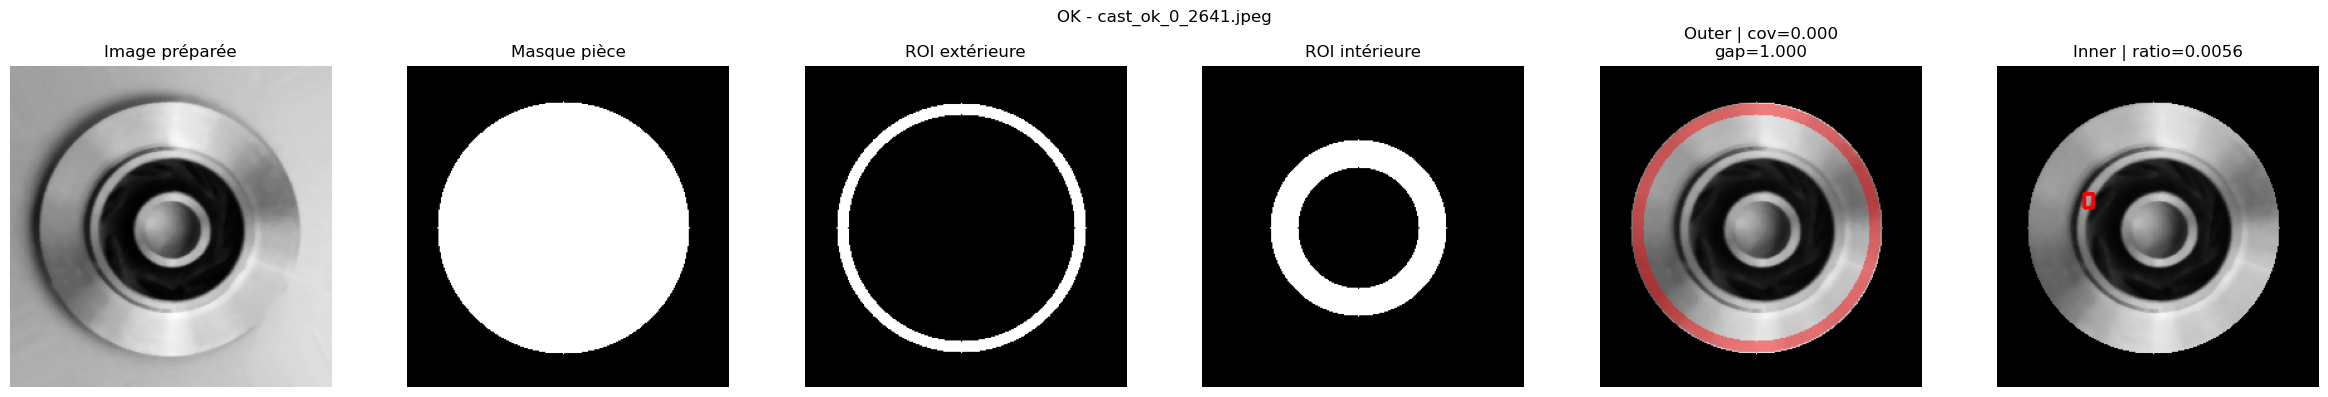

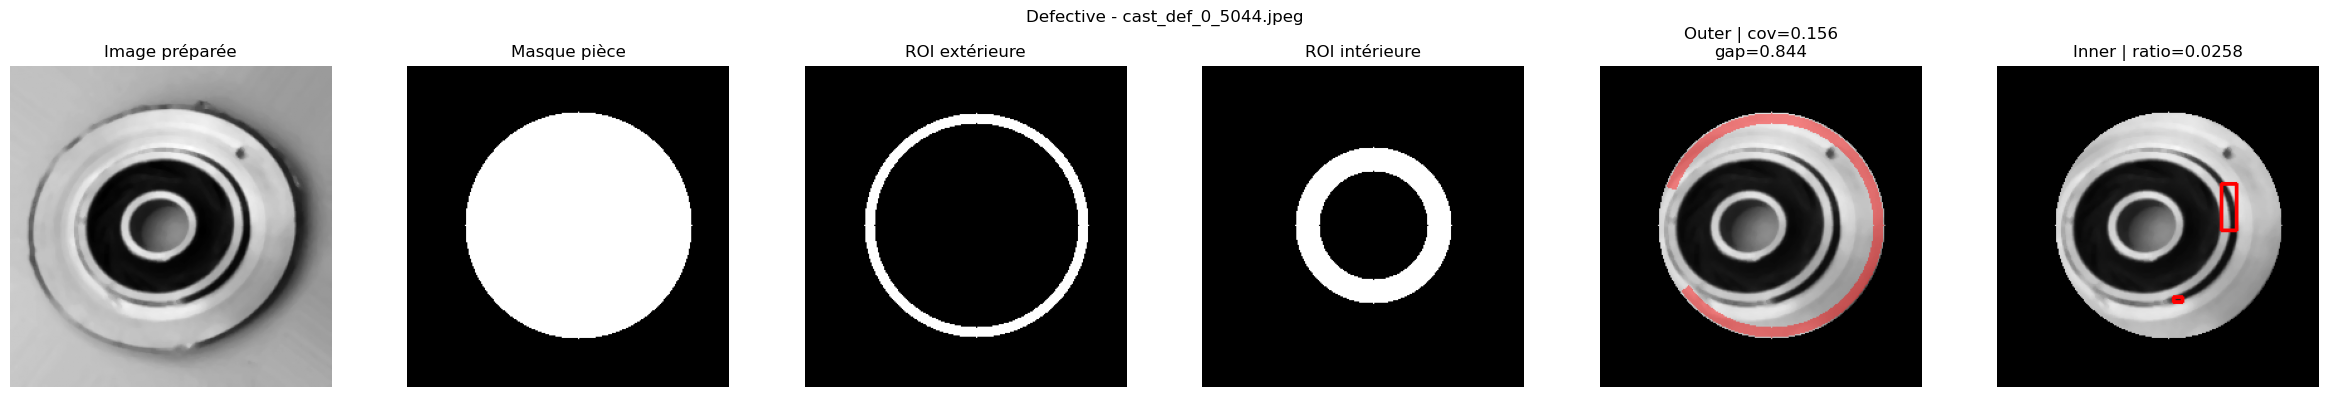

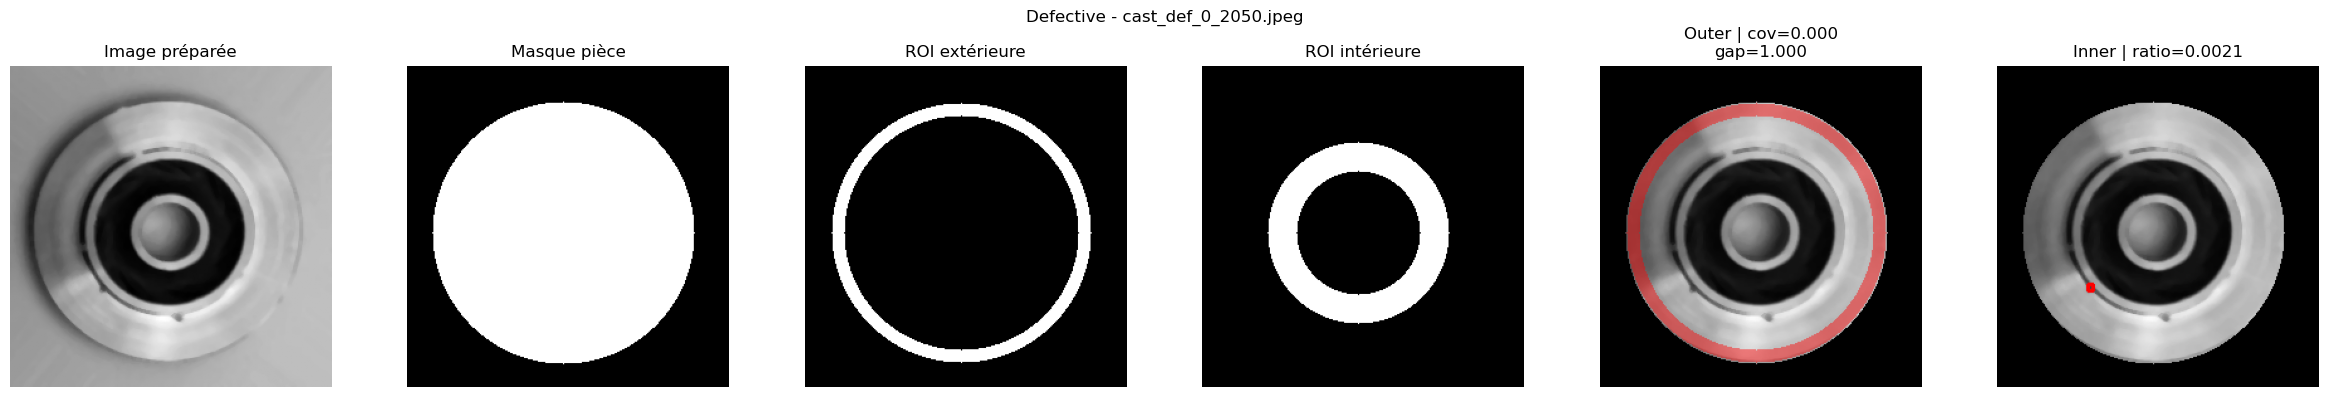

In [165]:
# ==========================================
# 23. Tester sur plusieurs images
# ==========================================

def show_segmentation_examples(image_paths, class_name, n=2):
    selected_paths = random.sample(image_paths, min(n, len(image_paths)))

    for path in selected_paths:
        img = load_grayscale_image(path)
        result = full_segmentation_pipeline_v2(img)

        if result is None:
            print(f"{path.name} -> segmentation impossible")
            continue

        outer_overlay = overlay_mask_on_gray(
            result["piece_only"],
            result["outer"]["gap_mask"],
            color=(255, 0, 0),
            alpha=0.45
        )

        inner_boxes = draw_bounding_boxes(
            result["piece_only"],
            result["inner"]["filtered_contours"],
            min_area=10
        )

        features = extract_features_from_result(result)

        fig, axes = plt.subplots(1, 6, figsize=(24, 4))

        axes[0].imshow(result["prepared"], cmap="gray")
        axes[0].set_title("Image préparée")
        axes[0].axis("off")

        axes[1].imshow(result["main_obj"]["mask"], cmap="gray")
        axes[1].set_title("Masque pièce")
        axes[1].axis("off")

        axes[2].imshow(result["roi_outer"], cmap="gray")
        axes[2].set_title("ROI extérieure")
        axes[2].axis("off")

        axes[3].imshow(result["roi_inner"], cmap="gray")
        axes[3].set_title("ROI intérieure")
        axes[3].axis("off")

        axes[4].imshow(outer_overlay)
        axes[4].set_title(
            f"Outer | cov={features['outer_coverage_ratio']:.3f}\n"
            f"gap={features['outer_largest_gap_ratio']:.3f}"
        )
        axes[4].axis("off")

        axes[5].imshow(inner_boxes)
        axes[5].set_title(f"Inner | ratio={features['inner_area_ratio']:.4f}")
        axes[5].axis("off")

        plt.suptitle(f"{class_name} - {path.name}")
        plt.tight_layout()
        plt.show()

show_segmentation_examples(train_ok_images, "OK", n=2)
show_segmentation_examples(train_def_images, "Defective", n=2)